# Maternal Health Risk - Classification
Predict patient `RiskLevel` (low / mid / high) from vital-sign features.

**Pipeline:** EDA -> Data-quality cleaning -> Feature selection -> Model comparison (CV) -> Hyperparameter tuning -> Final evaluation.

# 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier, BaggingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

# 2. Load Dataset

In [2]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')
df.head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.00,98.0,86,high risk
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk
7,35,85,60,11.00,102.0,86,high risk
8,32,120,90,6.90,98.0,70,mid risk
9,42,130,80,18.00,98.0,70,high risk


# 3. Dataset Information

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (1014, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [4]:
NUM_COLS = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
RISK_ORDER = ['low risk', 'mid risk', 'high risk']
df[NUM_COLS].describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


# 4. Exploratory Data Analysis

### 4.1 Class Distribution

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


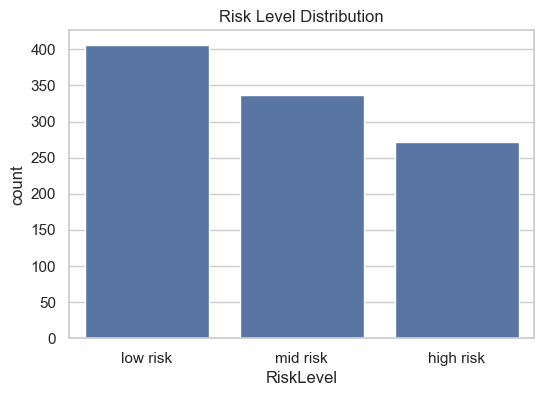

In [5]:
print(df['RiskLevel'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='RiskLevel', data=df, order=RISK_ORDER)
plt.title('Risk Level Distribution')
plt.show()

### 4.2 Missing Values

In [6]:
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Total missing: 0


### 4.3 Feature Distributions

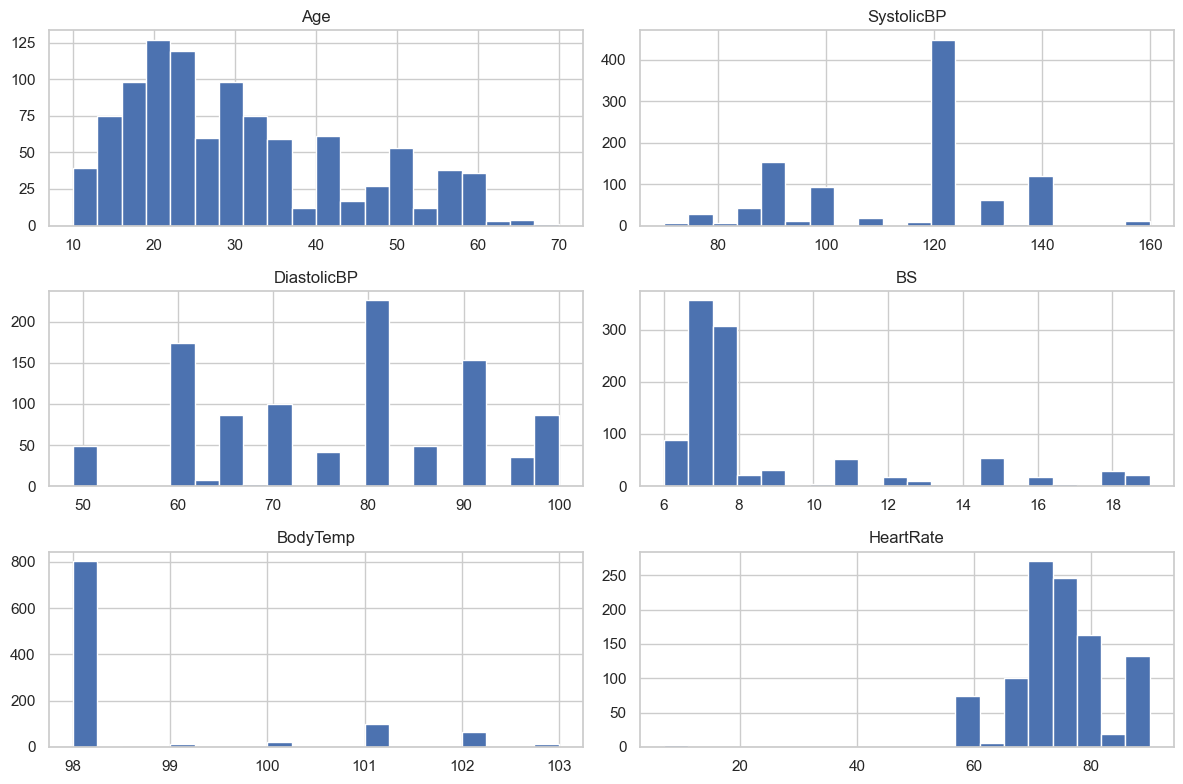

In [7]:
df[NUM_COLS].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

### 4.4 Outlier & Validity Check
Three complementary views:
1. **Box plots** for a quick visual scan of each feature's spread and extreme points.
2. **IQR audit (Tukey's fences)** — an explicit, numeric table counting outliers per feature (below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`), plus the actual outlier rows for the worst feature.
3. **Physiological sanity check** on `HeartRate` — a resting heart rate below 30 bpm is not viable and signals a data-entry error.

Note: most "outliers" here (high blood sugar, elevated BP) are **clinically real** high-risk readings, not errors — so we keep them. Only the impossible `HeartRate < 30` values are corrected in step 5.1.

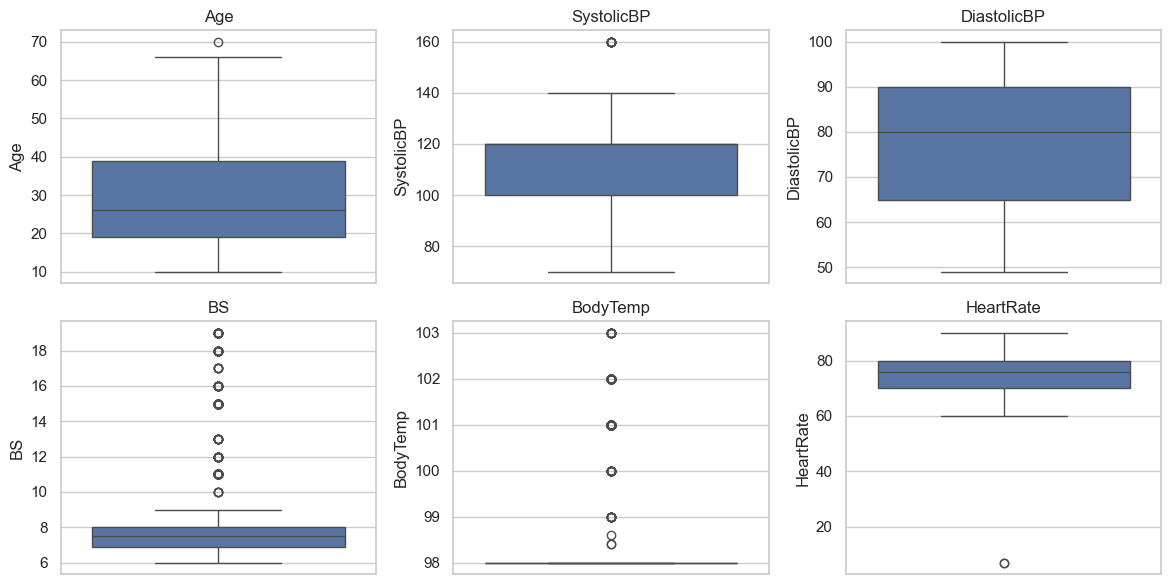

HeartRate minimum: 7
Rows with HeartRate < 30 (invalid): 2


In [8]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(NUM_COLS, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

print('HeartRate minimum:', df['HeartRate'].min())
print('Rows with HeartRate < 30 (invalid):', (df['HeartRate'] < 30).sum())

In [9]:
# Explicit outlier audit using the IQR rule (Tukey's fences).
# A value is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
outlier_summary = []
for col in NUM_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_summary.append({
        'feature': col,
        'lower_bound': round(low, 2),
        'upper_bound': round(high, 2),
        'n_outliers': int(mask.sum()),
        'pct': round(100 * mask.mean(), 1),
        'min_outlier': df.loc[mask, col].min() if mask.any() else np.nan,
        'max_outlier': df.loc[mask, col].max() if mask.any() else np.nan,
    })

outlier_summary = pd.DataFrame(outlier_summary).set_index('feature')
print('IQR-based outlier counts per feature:')
display(outlier_summary)

# Show the actual outlier rows for the most affected feature.
worst = outlier_summary['n_outliers'].idxmax()
q1, q3 = df[worst].quantile([0.25, 0.75])
iqr = q3 - q1
worst_mask = (df[worst] < q1 - 1.5 * iqr) | (df[worst] > q3 + 1.5 * iqr)
print(f'\nSample outlier rows for "{worst}" ({worst_mask.sum()} total):')
display(df.loc[worst_mask].head(10))

IQR-based outlier counts per feature:


,lower_bound,upper_bound,n_outliers,pct,min_outlier,max_outlier
feature,,,,,,
Age,-11.00,69.00,1,0.1,70.0,70.0
SystolicBP,70.00,150.00,10,1.0,160.0,160.0
DiastolicBP,27.50,127.50,0,0.0,NaN,NaN
BS,5.25,9.65,210,20.7,10.0,19.0
BodyTemp,98.00,98.00,210,20.7,98.4,103.0
HeartRate,55.00,95.00,2,0.2,7.0,7.0



Sample outlier rows for "BS" (210 total):


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
7,35,85,60,11.0,102.0,86,high risk
9,42,130,80,18.0,98.0,70,high risk
14,48,120,80,11.0,98.0,88,mid risk
16,50,140,90,15.0,98.0,90,high risk
20,40,140,100,18.0,98.0,90,high risk
73,54,130,70,12.0,98.0,67,mid risk
74,44,120,90,16.0,98.0,80,mid risk
77,55,120,90,12.0,98.0,70,mid risk


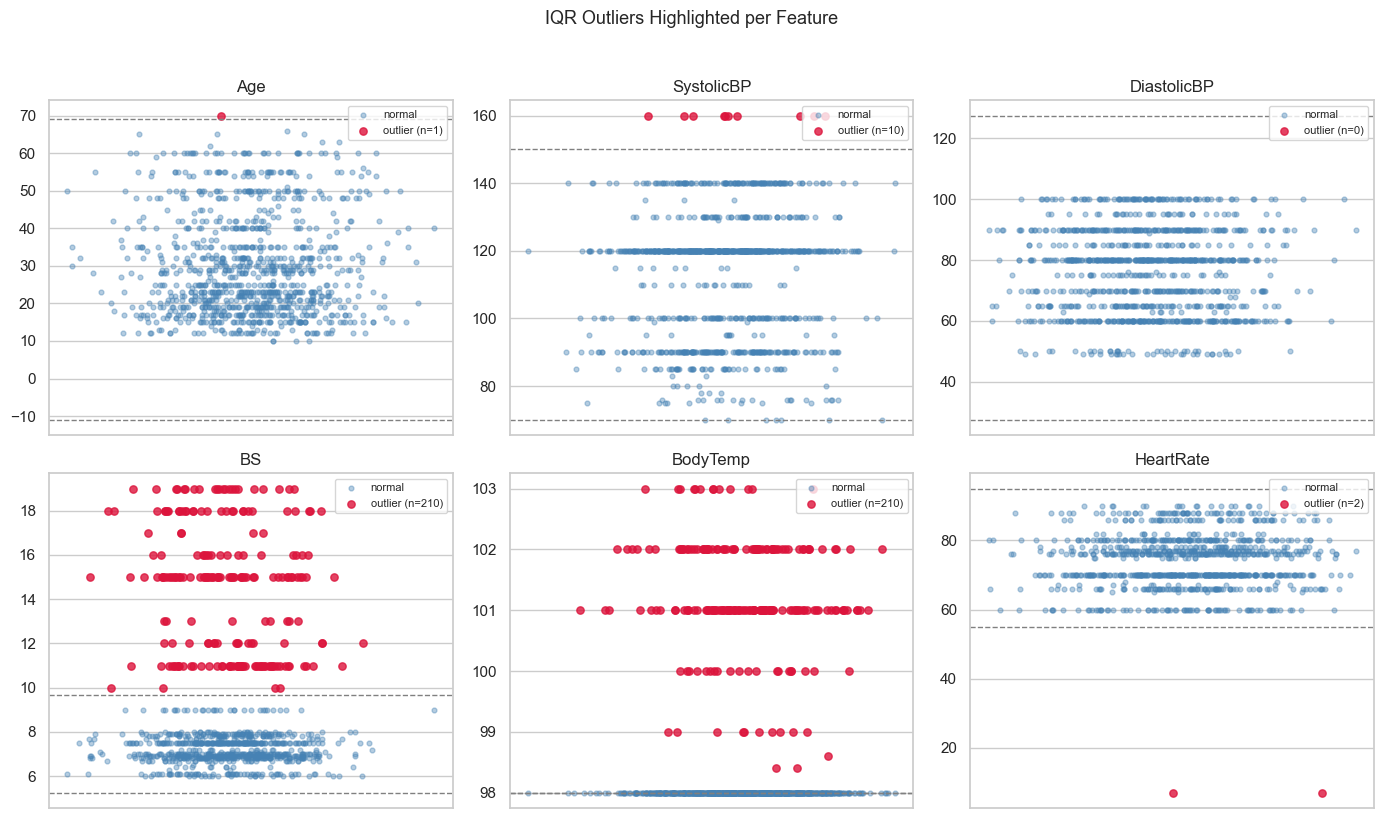

In [10]:
# Outlier graph: per feature, plot every value and highlight IQR outliers in red.
# Dashed lines mark the Tukey fences (Q1 - 1.5*IQR and Q3 + 1.5*IQR).
plt.figure(figsize=(14, 8))
for i, col in enumerate(NUM_COLS, 1):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)

    ax = plt.subplot(2, 3, i)
    # jitter the x-axis so overlapping points are visible
    x_norm = np.random.normal(0, 0.04, size=(~mask).sum())
    x_out  = np.random.normal(0, 0.04, size=mask.sum())
    ax.scatter(x_norm, df.loc[~mask, col], s=12, alpha=0.4,
               color='steelblue', label='normal')
    ax.scatter(x_out, df.loc[mask, col], s=28, alpha=0.8,
               color='crimson', label=f'outlier (n={int(mask.sum())})')
    ax.axhline(low, ls='--', color='gray', lw=1)
    ax.axhline(high, ls='--', color='gray', lw=1)
    ax.set_title(col)
    ax.set_xticks([])
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('IQR Outliers Highlighted per Feature', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

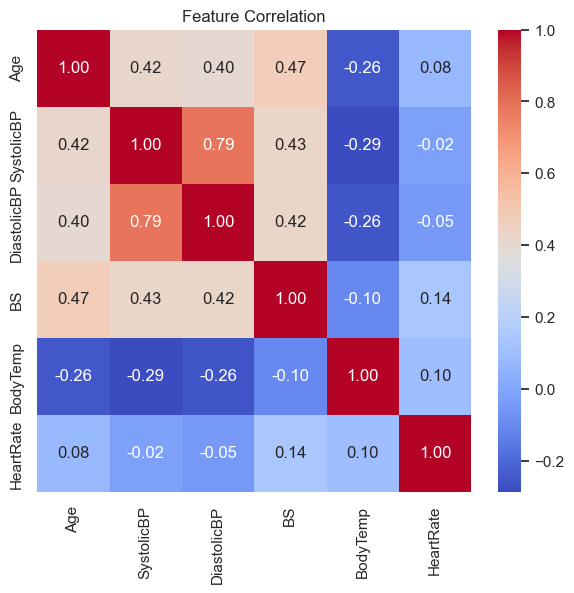

In [11]:
corr = df[NUM_COLS].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

### 4.6 Feature vs Risk Level

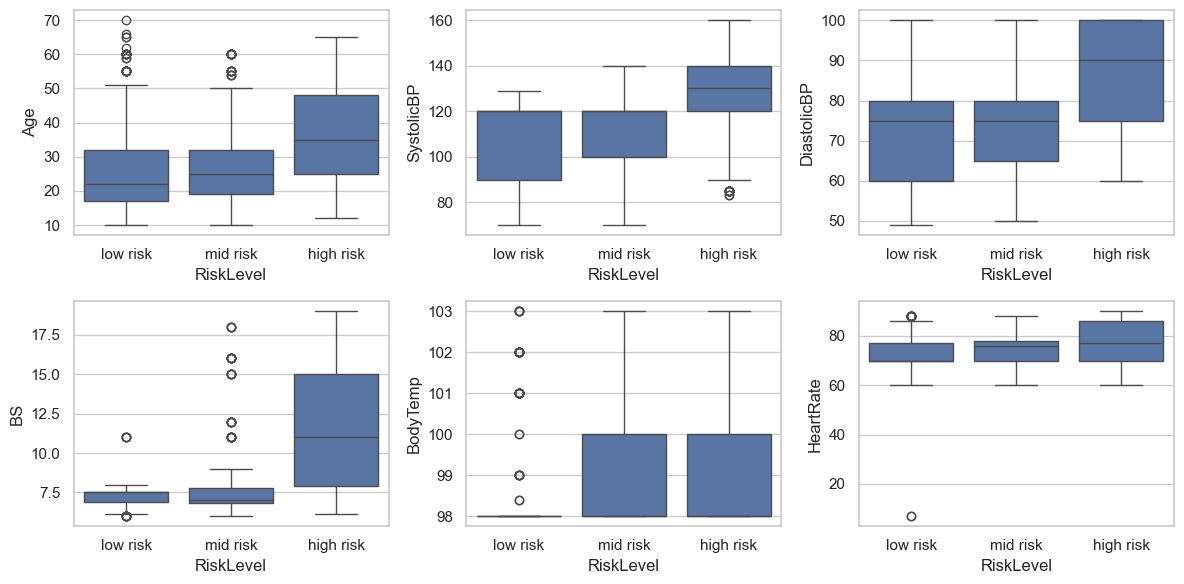

In [12]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(NUM_COLS, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='RiskLevel', y=col, data=df, order=RISK_ORDER)
plt.tight_layout()
plt.show()

### 4.7 Duplicate Analysis
The dataset contains many repeated rows, but **they are kept on purpose.**

In maternal-health data two *different* patients can genuinely have the same Age, blood pressure, blood sugar, temperature and heart rate - the features are coarse (`BodyTemp` has only 8 distinct values; BP and blood sugar are rounded). The repeats are **not** data-entry errors, they are real patients, and they reflect how common each vital-sign combination is in the population. Deleting them would throw away genuine information, so **all 1014 rows are retained**. The only values we correct are physiologically *invalid* ones (`HeartRate < 30`).

In [13]:
print('Exact duplicate rows:', df.duplicated().sum())
# Identical features but a DIFFERENT label => inherent class overlap, not duplication
conflict = df.groupby(NUM_COLS)['RiskLevel'].nunique()
print('Feature combos mapping to conflicting labels:', (conflict > 1).sum())

Exact duplicate rows: 562
Feature combos mapping to conflicting labels: 35


# 5. Data Preprocessing

### 5.1 Fix Invalid Heart-Rate Values
Replace the impossible `HeartRate` readings (< 30 bpm) with the column median. No rows are deleted - the record count stays at 1014.

In [14]:
df['HeartRate'] = df['HeartRate'].mask(df['HeartRate'] < 30, np.nan)
df['HeartRate'] = df['HeartRate'].fillna(df['HeartRate'].median())
print('HeartRate minimum after cleaning:', df['HeartRate'].min())
print('Rows retained:', df.shape[0])

HeartRate minimum after cleaning: 60.0
Rows retained: 1014


### 5.2 Encode the Target

In [15]:
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel_Encoded'] = df['RiskLevel'].map(risk_mapping)
df[['RiskLevel', 'RiskLevel_Encoded']].head()

,RiskLevel,RiskLevel_Encoded
0,high risk,2
1,high risk,2
2,high risk,2
3,high risk,2
4,low risk,0


# 6. Feature Selection
We rank features two ways - **mutual information** (model-free dependence) and **Random-Forest impurity importance** - and check whether dropping the weakest helps.

,mutual_info,rf_importance
BS,0.315014,0.362464
SystolicBP,0.251092,0.186596
Age,0.231149,0.161181
DiastolicBP,0.125031,0.122974
HeartRate,0.100846,0.103894
BodyTemp,0.042907,0.062892


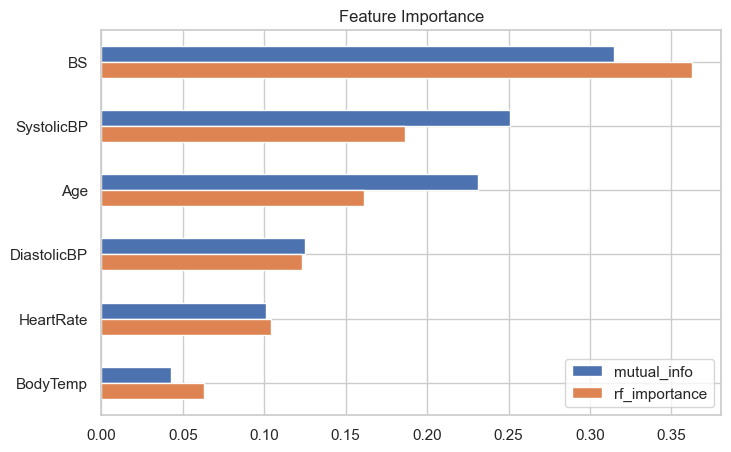

In [16]:
X = df[NUM_COLS]
y = df['RiskLevel_Encoded']

mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
rf_imp = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X, y).feature_importances_

importance = (pd.DataFrame({'mutual_info': mi, 'rf_importance': rf_imp}, index=NUM_COLS)
              .sort_values('rf_importance', ascending=False))
display(importance)

importance.plot.barh(figsize=(8, 5))
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [17]:
# Does removing the weakest feature (BodyTemp) help? Compare with stratified CV.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ref = ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE)
for cols in [NUM_COLS, [col for col in NUM_COLS if col != 'BodyTemp']]:
    s = cross_val_score(ref, X[cols], y, cv=cv, scoring='accuracy').mean()
    print(f'{len(cols)} features  acc={s:.3f}  {cols}')

6 features  acc=0.859  ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
5 features  acc=0.863  ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate']


All six features carry signal and the difference from dropping `BodyTemp` is within noise, so we **keep all six features**. `BS` (blood sugar) is by far the strongest predictor.

# 7. Train / Test Split & Scaling
Stratified 80/20 split. Scaling is fit on the training set only (and matters only for the linear / distance-based models - the tree ensembles are scale-invariant).

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (811, 6)  Test: (203, 6)


# 8. Model Training & Comparison (all ML algorithms, 5-fold Stratified CV)
We train a wide range of classifiers - linear models, discriminant analysis, naive Bayes, KNN, SVMs, a neural network, single trees and every major ensemble - and compare them with cross-validated accuracy on the training set. Scale-sensitive models are wrapped in a pipeline so scaling happens inside each fold (no leakage).

,cv_accuracy,cv_f1_macro
Random Forest,0.834,0.837
HistGradientBoosting,0.827,0.831
Extra Trees,0.822,0.825
Bagging,0.820,0.824
Decision Tree,0.808,0.812
Gradient Boosting,0.793,0.797
MLP (Neural Net),0.704,0.704
SVM (RBF),0.690,0.683
KNN,0.673,0.675
AdaBoost,0.665,0.660


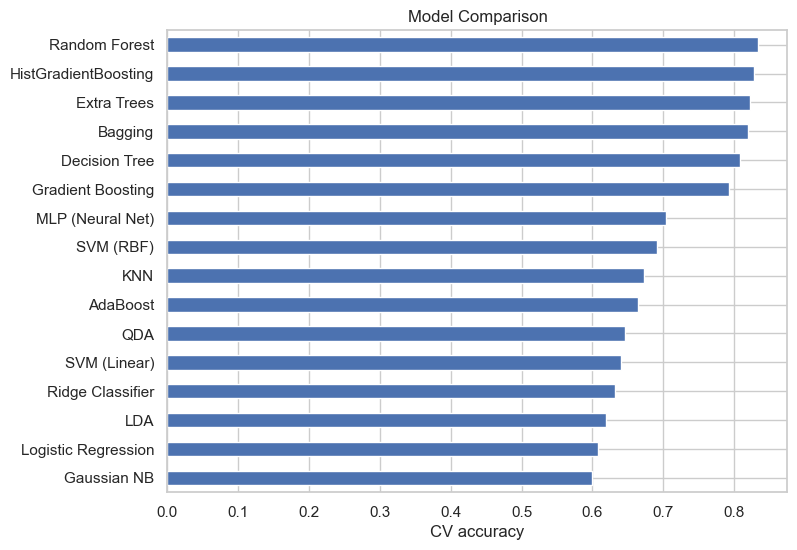

In [19]:
def scaled(estimator):
    return Pipeline([('sc', StandardScaler()), ('m', estimator)])

models = {
    'Logistic Regression':  scaled(LogisticRegression(max_iter=2000)),
    'Ridge Classifier':     scaled(RidgeClassifier()),
    'LDA':                  scaled(LinearDiscriminantAnalysis()),
    'QDA':                  scaled(QuadraticDiscriminantAnalysis()),
    'Gaussian NB':          scaled(GaussianNB()),
    'KNN':                  scaled(KNeighborsClassifier()),
    'SVM (RBF)':            scaled(SVC(random_state=RANDOM_STATE)),
    'SVM (Linear)':         scaled(SVC(kernel='linear', random_state=RANDOM_STATE)),
    'MLP (Neural Net)':     scaled(MLPClassifier(max_iter=1000, random_state=RANDOM_STATE)),
    'Decision Tree':        DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost':             AdaBoostClassifier(random_state=RANDOM_STATE),
    'Bagging':              BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    results[name] = {'cv_accuracy': acc, 'cv_f1_macro': f1}

results_df = pd.DataFrame(results).T.sort_values('cv_accuracy', ascending=False)
display(results_df.round(3))

results_df['cv_accuracy'].plot.barh(figsize=(8, 6))
plt.gca().invert_yaxis()
plt.xlabel('CV accuracy')
plt.title('Model Comparison')
plt.show()

# 9. Hyperparameter Tuning (best model)
We take the top model from the comparison and tune it with grid search over the same CV folds.

In [20]:
best_name = results_df.index[0]
print('Best model from comparison:', best_name)

param_grids = {
    'Random Forest':        {'n_estimators': [300, 500], 'max_depth': [None, 20],
                             'min_samples_leaf': [1, 2], 'max_features': ['sqrt', None]},
    'Extra Trees':          {'n_estimators': [300, 500], 'max_depth': [None, 20],
                             'min_samples_leaf': [1, 2], 'max_features': ['sqrt', None]},
    'HistGradientBoosting': {'max_iter': [200, 400], 'max_depth': [None, 6],
                             'learning_rate': [0.05, 0.1], 'l2_regularization': [0.0, 1.0]},
    'Gradient Boosting':    {'n_estimators': [200, 400], 'max_depth': [2, 3],
                             'learning_rate': [0.05, 0.1]},
    'Bagging':              {'n_estimators': [100, 300], 'max_samples': [0.7, 1.0]},
}
estimators = {
    'Random Forest':        RandomForestClassifier(random_state=RANDOM_STATE),
    'Extra Trees':          ExtraTreesClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Bagging':              BaggingClassifier(random_state=RANDOM_STATE),
}

if best_name in param_grids:
    grid = GridSearchCV(estimators[best_name], param_grids[best_name],
                        cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print('Best CV accuracy:', round(grid.best_score_, 3))
    print('Best params:', grid.best_params_)
    best_model = grid.best_estimator_
else:
    # Non-tree winner: refit the untuned pipeline as-is.
    best_model = models[best_name].fit(X_train, y_train)
    print('Using default hyperparameters for', best_name)

Best model from comparison: Random Forest
Best CV accuracy: 0.834
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


# 10. Final Evaluation on the Held-out Test Set

Final model: Random Forest
Test accuracy: 0.852
Test macro-F1 : 0.856

Classification report:
              precision    recall  f1-score   support

    low risk       0.86      0.83      0.84        81
    mid risk       0.82      0.79      0.80        67
   high risk       0.88      0.96      0.92        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.86       203
weighted avg       0.85      0.85      0.85       203



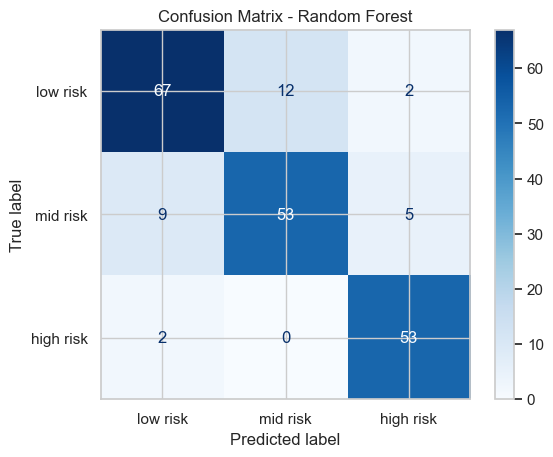

In [21]:
y_pred = best_model.predict(X_test)

print('Final model:', best_name)
print('Test accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Test macro-F1 :', round(f1_score(y_test, y_pred, average='macro'), 3))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=RISK_ORDER))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=RISK_ORDER).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

# 11. Ensemble of the Top-5 Models
The five strongest single models from section 8 were **Random Forest, HistGradientBoosting, Extra Trees, Bagging and Decision Tree**.

We combine them with a **soft-voting** ensemble (averages predicted class probabilities) and search **every 3- and 4-model combination** of these five to find the blend with the best cross-validated accuracy. Combining diverse tree learners usually reduces variance and lifts accuracy above any single model. All are scale-invariant, so no scaling is needed.

In [22]:
from itertools import combinations
from sklearn.ensemble import VotingClassifier

# The 5 top single models (using the tuned RF settings found in section 9).
base_estimators = {
    'Random Forest':        RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                                    min_samples_leaf=1, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE),
    'Bagging':              BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Decision Tree':        DecisionTreeClassifier(random_state=RANDOM_STATE),
}

# Try every 3- and 4-model combination, scored with the same 5-fold stratified CV.
combo_results = []
for k in (3, 4):
    for names in combinations(base_estimators, k):
        ens = VotingClassifier(
            estimators=[(n, base_estimators[n]) for n in names],
            voting='soft')
        acc = cross_val_score(ens, X_train, y_train, cv=cv, scoring='accuracy').mean()
        f1  = cross_val_score(ens, X_train, y_train, cv=cv, scoring='f1_macro').mean()
        combo_results.append({'n_models': k, 'combination': ' + '.join(names),
                              'cv_accuracy': acc, 'cv_f1_macro': f1})

combo_df = (pd.DataFrame(combo_results)
            .sort_values('cv_accuracy', ascending=False)
            .reset_index(drop=True))
print('All 3/4-model ensemble combinations (best first):')
display(combo_df.round(3))

All 3/4-model ensemble combinations (best first):


,n_models,combination,cv_accuracy,cv_f1_macro
0,3,Random Forest + HistGradientBoosting + Extra T...,0.837,0.841
1,3,HistGradientBoosting + Extra Trees + Bagging,0.836,0.840
2,3,Random Forest + HistGradientBoosting + Bagging,0.835,0.838
3,4,Random Forest + HistGradientBoosting + Extra T...,0.833,0.837
4,4,Random Forest + HistGradientBoosting + Extra T...,0.832,0.836
5,3,Random Forest + Extra Trees + Bagging,0.831,0.834
6,3,HistGradientBoosting + Extra Trees + Decision ...,0.831,0.835
7,3,Random Forest + HistGradientBoosting + Decisio...,0.830,0.834
8,4,HistGradientBoosting + Extra Trees + Bagging +...,0.829,0.832
9,4,Random Forest + HistGradientBoosting + Bagging...,0.827,0.832


Best ensemble combination: Random Forest + HistGradientBoosting + Extra Trees
CV accuracy: 0.837 | CV macro-F1: 0.841

Test accuracy: 0.852
Test macro-F1 : 0.856

Classification report:
              precision    recall  f1-score   support

    low risk       0.86      0.83      0.84        81
    mid risk       0.82      0.79      0.80        67
   high risk       0.88      0.96      0.92        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.86       203
weighted avg       0.85      0.85      0.85       203



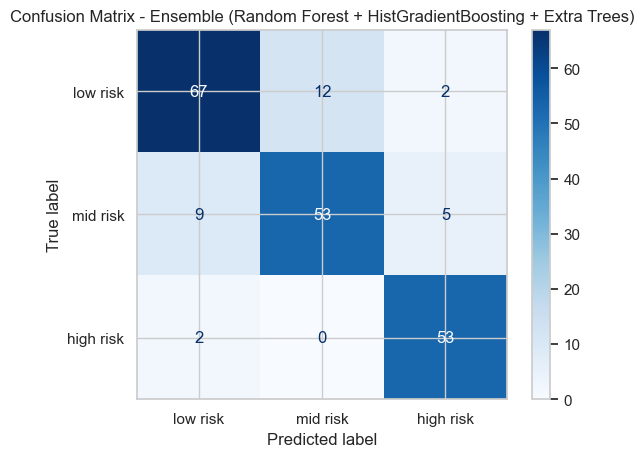

Single best model (Random Forest):  test acc = 0.852
Best ensemble:           test acc = 0.852


In [23]:
# Take the best-scoring combination, fit on the full training set, evaluate on the held-out test set.
best_combo = combo_df.iloc[0]['combination']
best_names = best_combo.split(' + ')
print('Best ensemble combination:', best_combo)
print('CV accuracy:', round(combo_df.iloc[0]['cv_accuracy'], 3),
      '| CV macro-F1:', round(combo_df.iloc[0]['cv_f1_macro'], 3))

ensemble = VotingClassifier(
    estimators=[(n, base_estimators[n]) for n in best_names],
    voting='soft').fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)
print('\nTest accuracy:', round(accuracy_score(y_test, y_pred_ens), 3))
print('Test macro-F1 :', round(f1_score(y_test, y_pred_ens, average='macro'), 3))
print('\nClassification report:')
print(classification_report(y_test, y_pred_ens, target_names=RISK_ORDER))

cm = confusion_matrix(y_test, y_pred_ens)
ConfusionMatrixDisplay(cm, display_labels=RISK_ORDER).plot(cmap='Blues')
plt.title(f'Confusion Matrix - Ensemble ({best_combo})')
plt.show()

# Compare the ensemble against the single best model from section 10.
print('Single best model ({}):  test acc = {:.3f}'.format(
    best_name, accuracy_score(y_test, y_pred)))
print('Best ensemble:           test acc = {:.3f}'.format(
    accuracy_score(y_test, y_pred_ens)))